## 4. Key Insights

- **Trend Following**: SMA/EMA crossovers are reliable trend confirmation signals. When price is above both averages, an uptrend is in effect.
- **Momentum Trading**: RSI extreme values (>70 or <30) often precede reversals, offering entry/exit signals.
- **Risk Management**: Combining multiple indicators reduces false signals; EMA is more responsive than SMA for tactical decisions.

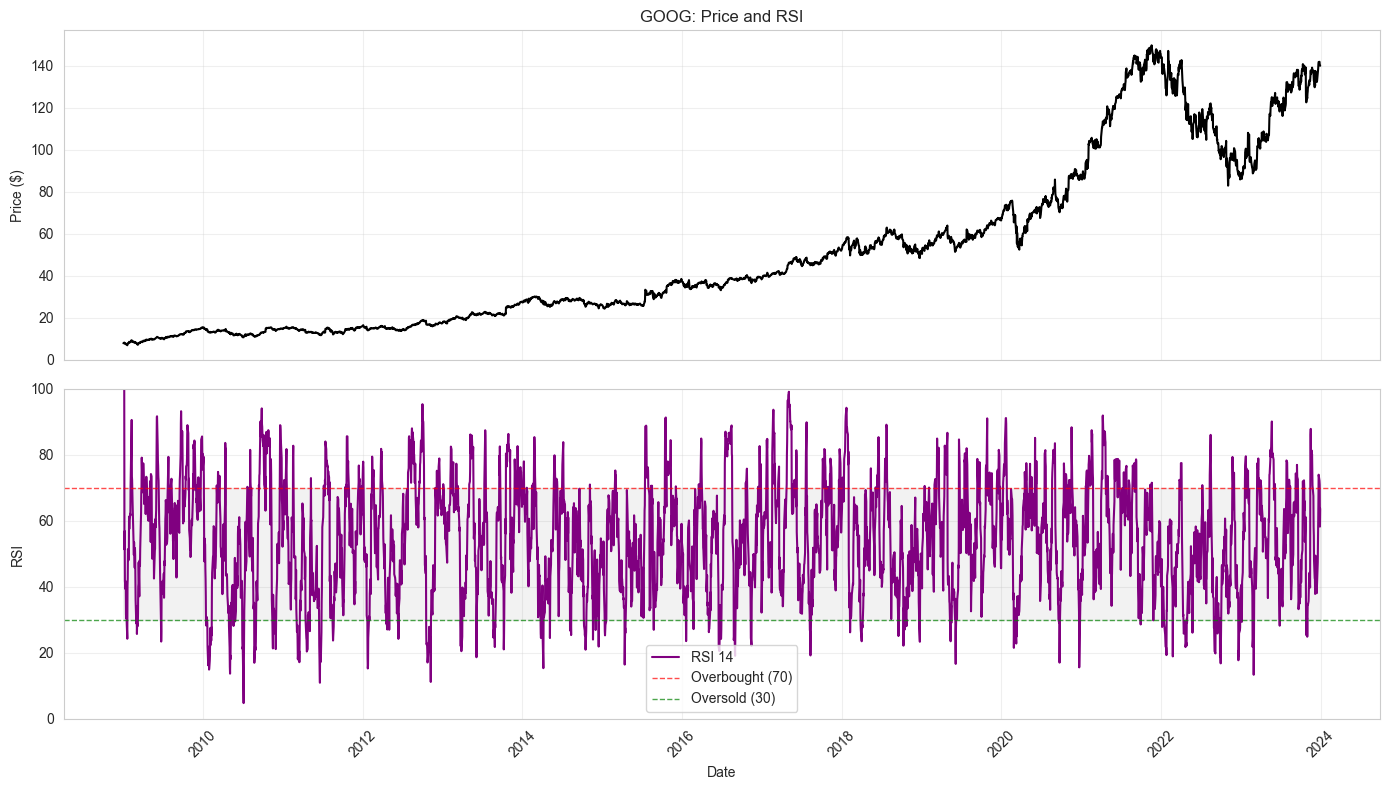


Current RSI: 63.74
  → NEUTRAL — No extreme condition; normal momentum range


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Price
ax1.plot(df['Date'], df['Close'], color='black', linewidth=1.5)
ax1.set_ylabel('Price ($)')
ax1.set_title('GOOG: Price and RSI')
ax1.grid(alpha=0.3)

# Bottom: RSI
ax2.plot(df['Date'], df['RSI_14'], color='purple', linewidth=1.5, label='RSI 14')
ax2.axhline(70, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Oversold (30)')
ax2.fill_between(df['Date'], 30, 70, alpha=0.1, color='gray')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Current RSI status
current_rsi = df['RSI_14'].iloc[-1]
print(f"\nCurrent RSI: {current_rsi:.2f}")
if current_rsi > 70:
    print(f"  ⚠️  OVERBOUGHT — Potential downside risk; consider profit-taking")
elif current_rsi < 30:
    print(f"  ✓ OVERSOLD — Potential upside opportunity; watch for reversal")
else:
    print(f"  → NEUTRAL — No extreme condition; normal momentum range")

## 3. Relative Strength Index (RSI)

RSI oscillates between 0–100. Readings above 70 indicate overbought conditions (potential pullback); below 30 indicate oversold conditions (potential bounce).

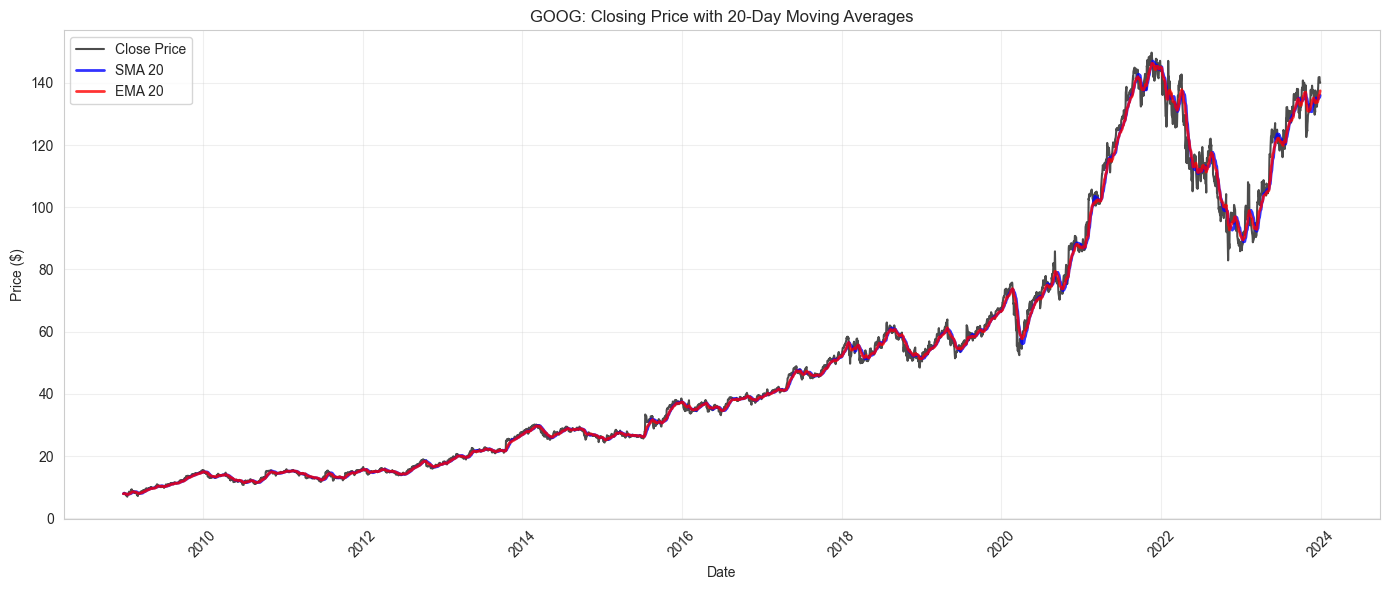


Most Recent Data Point (2023-12-29 00:00:00):
  Close: $139.97
  SMA 20: $135.98
  EMA 20: $137.41

Trend Interpretation:
  ✓ Price above 20-day SMA → UPTREND (bullish)
  ✓ EMA > SMA → Recent momentum stronger than average → BULLISH


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot price and moving averages
ax.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5, alpha=0.7)
ax.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=2, alpha=0.8)
ax.plot(df['Date'], df['EMA_20'], label='EMA 20', color='red', linewidth=2, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.set_title('GOOG: Closing Price with 20-Day Moving Averages')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interpretation
recent = df.iloc[-1]
print(f"\nMost Recent Data Point ({recent['Date']}):")
print(f"  Close: ${recent['Close']:.2f}")
print(f"  SMA 20: ${recent['SMA_20']:.2f}")
print(f"  EMA 20: ${recent['EMA_20']:.2f}")
print(f"\nTrend Interpretation:")
if recent['Close'] > recent['SMA_20']:
    print(f"  ✓ Price above 20-day SMA → UPTREND (bullish)")
else:
    print(f"  ✗ Price below 20-day SMA → DOWNTREND (bearish)")
if recent['EMA_20'] > recent['SMA_20']:
    print(f"  ✓ EMA > SMA → Recent momentum stronger than average → BULLISH")

## 2. Price with Moving Averages

Plot the closing price overlaid with SMA and EMA to visualize trend direction and support/resistance levels.

In [10]:
# Compute indicators
df['SMA_20'] = compute_sma(df, 'Close', window=20)
df['EMA_20'] = compute_ema(df, 'Close', span=20)
df['RSI_14'] = compute_rsi(df, 'Close', window=14)
df['Daily_Return'] = compute_returns(df, 'Close')

# Display recent values
print("Recent Indicator Values:")
print(df[['Date', 'Close', 'SMA_20', 'EMA_20', 'RSI_14', 'Daily_Return']].tail(10))

Recent Indicator Values:
           Date       Close      SMA_20      EMA_20     RSI_14  Daily_Return
3764 2023-12-15  132.930344  134.624729  133.658729  41.529258      0.480504
3765 2023-12-18  136.257538  134.637142  133.906234  47.412219      2.502961
3766 2023-12-19  137.161362  134.646081  134.216247  53.229484      0.663320
3767 2023-12-20  138.710785  134.697729  134.644298  61.299229      1.129635
3768 2023-12-21  140.836227  134.786124  135.234005  65.738697      1.532284
3769 2023-12-22  141.750000  135.009596  135.854576  74.016699      0.648819
3770 2023-12-26  141.849304  135.246477  136.425503  72.182037      0.070056
3771 2023-12-27  140.478683  135.386520  136.811520  70.915160     -0.966251
3772 2023-12-28  140.319748  135.628861  137.145637  58.289315     -0.113139
3773 2023-12-29  139.972137  135.976979  137.414827  63.741198     -0.247727


## 1. Computing Technical Indicators

We compute three key indicators:
- **SMA (Simple Moving Average)**: 20-day average price; slower trend indicator
- **EMA (Exponential Moving Average)**: 20-day weighted average; faster response to recent price changes
- **RSI (Relative Strength Index)**: 14-day momentum oscillator; identifies overbought/oversold conditions

In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock
from src.indicators import compute_sma, compute_ema, compute_rsi, compute_returns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# Load GOOG stock data (highest correlation with sentiment)
print("Loading GOOG stock data...")
df = load_stock('GOOG.csv')
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
print(f"Loaded {len(df)} trading days")
print(df.head())

Loading GOOG stock data...


Loaded 3774 trading days
        Date     Close      High       Low      Open     Volume
0 2009-01-02  7.948608  7.960977  7.557264  7.633949  144961322
1 2009-01-05  8.115089  8.194003  7.792268  7.940692  196293007
2 2009-01-06  8.263762  8.430492  8.074027  8.237046  257971329
3 2009-01-07  7.965677  8.185839  7.885034  8.121770  180453860
4 2009-01-08  8.044340  8.044340  7.850152  7.873406  144567852


# Technical Indicators Analysis

This notebook computes and visualizes key technical indicators (SMA, EMA, RSI) for stock price analysis, providing insights into trend direction and momentum.